In [109]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [110]:
DATA_FOLDER = "preprocessed_avoiding"
PHASE_ORDER = [("Pre-Test", "reaching"), 
               ("Pre-Test", "avoiding"), 
               ("Training", "avoiding"),
               ("Post-Test", "reaching"), 
               ("Recap", "avoiding"),  
               ("Post-Test", "avoiding")]

In [111]:
ai_block = pd.read_csv(f"{DATA_FOLDER}/ai_block_measures.csv")
ad_block = pd.read_csv(f"{DATA_FOLDER}/ad_block_measures.csv")

In [112]:
ai_relevant = pd.read_csv(f"{DATA_FOLDER}/ai_relevant_trials.csv")
ad_relevant = pd.read_csv(f"{DATA_FOLDER}/ad_relevant_trials.csv")

In [113]:
ai = pd.read_csv(f"{DATA_FOLDER}/ai.csv")
ad = pd.read_csv(f"{DATA_FOLDER}/ad.csv")

#  Plot trajectories

In [114]:
from helpers import Trial
from helpers.metadata import PIXEL_RAILWAY_WIDTH, PIXEL_RAIL_TOP, PIXEL_RAIL_BOTTOM

In [115]:
RAIL_WIDTH_CM = Trial._transform_px_to_cm(PIXEL_RAILWAY_WIDTH, 0)
RAIL_HEIGHT_CM = Trial._transform_px_to_cm(PIXEL_RAIL_TOP - PIXEL_RAIL_BOTTOM, 1)

[np.float64(3.922), np.float64(7.522), np.float64(11.122), np.float64(14.722), np.float64(18.322), np.float64(22.122), np.float64(25.522)]
[np.float64(3.922), np.float64(7.522), np.float64(11.122), np.float64(14.722), np.float64(18.322), np.float64(22.122), np.float64(25.522)]
[np.float64(3.922), np.float64(11.122), np.float64(18.322), np.float64(25.522)]
[np.float64(3.922), np.float64(11.122), np.float64(18.322), np.float64(25.522)]
[np.float64(3.922), np.float64(11.122), np.float64(18.322), np.float64(25.522)]
[np.float64(3.922), np.float64(11.122), np.float64(18.322), np.float64(25.522)]
[np.float64(3.922), np.float64(11.122), np.float64(18.322), np.float64(25.522)]
[np.float64(3.922), np.float64(7.522), np.float64(11.122), np.float64(14.722), np.float64(18.322), np.float64(22.122), np.float64(25.522)]
[np.float64(3.922), np.float64(11.122), np.float64(18.322), np.float64(25.522)]
[np.float64(3.922), np.float64(7.522), np.float64(11.122), np.float64(14.722), np.float64(18.322), np.f

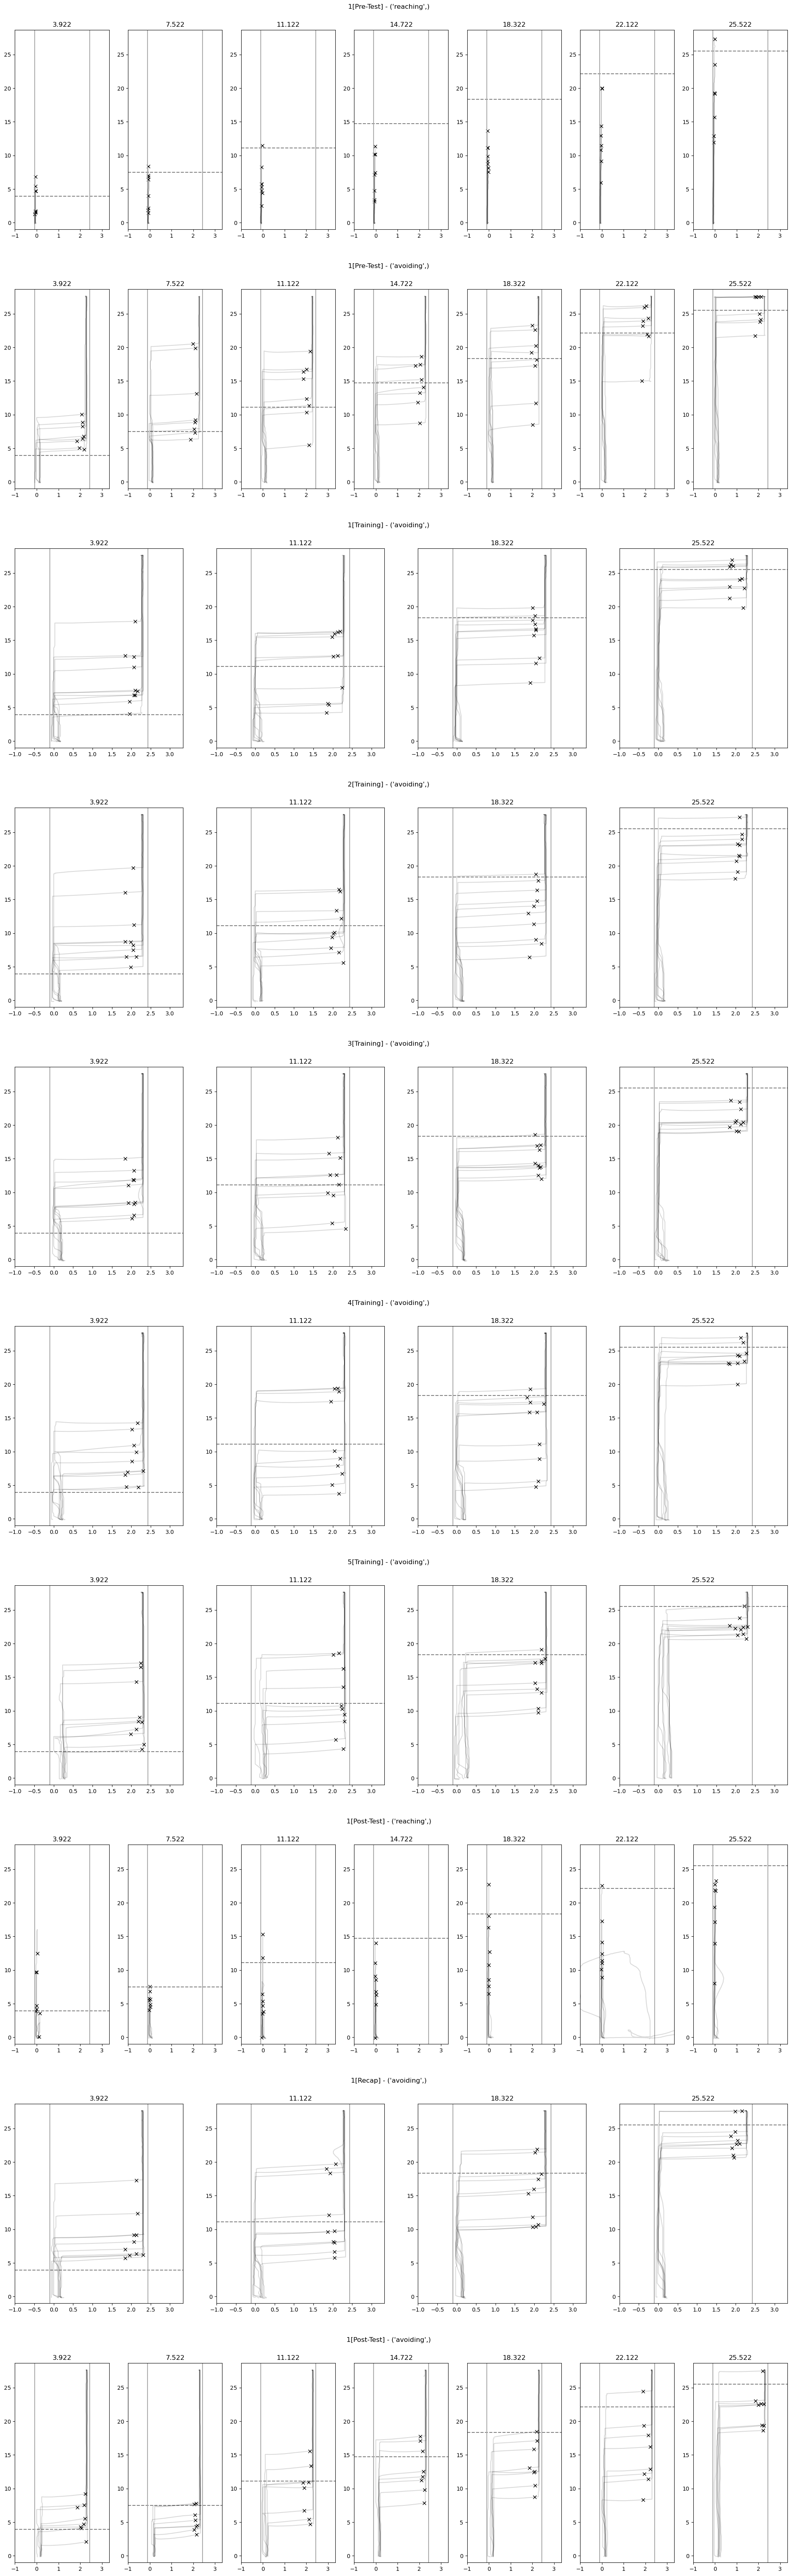

In [117]:
participant_id = "8ai"

cond = ai
cond_rel = ai_relevant

figure = plt.figure(figsize=(25, 65))

mapping = cond["mapping"].iloc[0]
natural = cond["natural_mapping"].iloc[0]

participant_trials = cond[(cond["participant_id"] == participant_id)]
subfigures = figure.subfigures(participant_trials.groupby(["phase", "block", "task"]).ngroups, 1)
subfig_nr = 0

for phase, task in PHASE_ORDER:

    phase_task_trials = participant_trials[(participant_trials["phase"] == phase) & (participant_trials["task"] == task)]
    for block in sorted(phase_task_trials["block"].unique()):
        
        block_trials = phase_task_trials[phase_task_trials["block"] == block]
        natural = participant_trials["natural_mapping"].iloc[0]
        for task, task_trials in block_trials.groupby(["task"]):
            
            axs = subfigures[subfig_nr].subplots(1, len(block_trials["target_pos_y_cm"].unique()))
            subfigures[subfig_nr].suptitle(f"{block}[{phase}] - {task}")

            axis_nr = 0
            print(sorted(task_trials["target_pos_y_cm"].unique()))
            targets = sorted(task_trials["target_pos_y_cm"].unique())
            for distance in targets:
                distance_trials = task_trials[task_trials["target_pos_y_cm"] == distance]

                axs[axis_nr].set_title(f"{distance}")
                axs[axis_nr].axhline(distance, linestyle="--", color="gray")

                axs[axis_nr].set_xlim(-1, RAIL_WIDTH_CM + 1)
                axs[axis_nr].set_ylim(-1, RAIL_HEIGHT_CM + 1)
                axs[axis_nr].axvline(-0.1, color="darkgray")
                axs[axis_nr].axvline(RAIL_WIDTH_CM+0.1, color="darkgray")

                for trial_index, trial in distance_trials.groupby(["trial_index"]):
                    axs[axis_nr].plot(trial["current_pos_x_cm"], trial["current_pos_y_cm"], c="k", alpha=0.15)

                    identified_relevant = cond_rel[(cond_rel["participant_id"] == participant_id) & (cond_rel["trial_index"] == trial_index)]
                    axs[axis_nr].scatter(identified_relevant["current_pos_x_cm"].iloc[0], identified_relevant["current_pos_y_cm"].iloc[0], marker="x" , linewidths=1, c="k")

                axis_nr += 1

            subfig_nr += 1

plt.savefig(f"{DATA_FOLDER}/figures/{participant_id}_{mapping}_natural_{natural}")

# Plot mean and variance

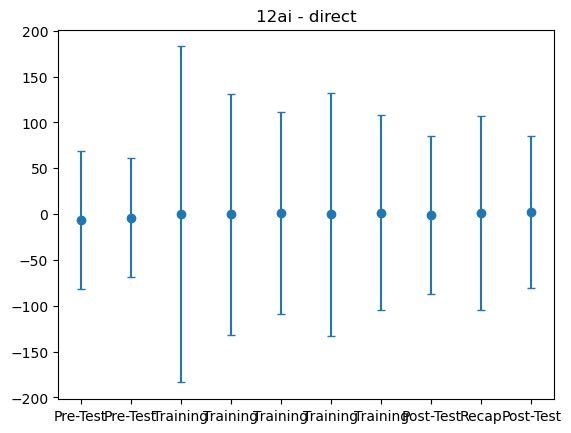

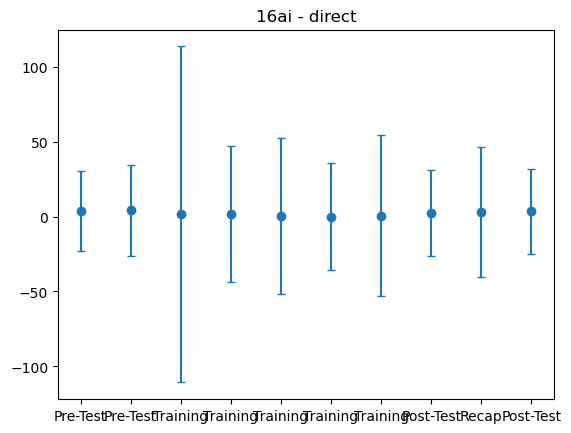

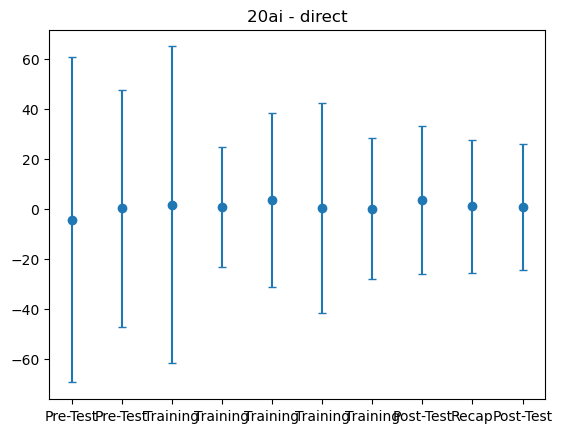

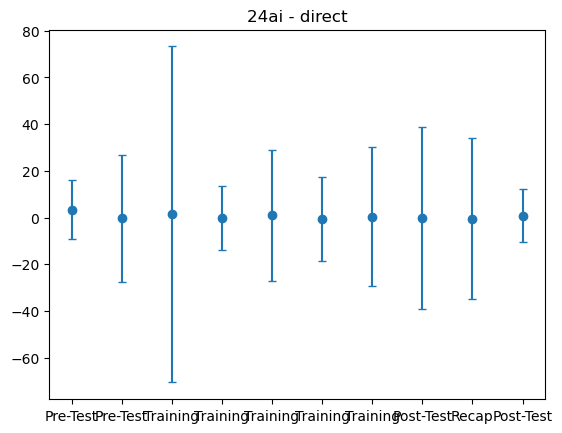

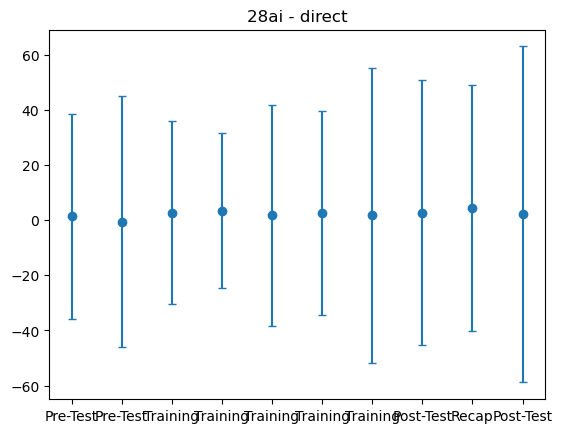

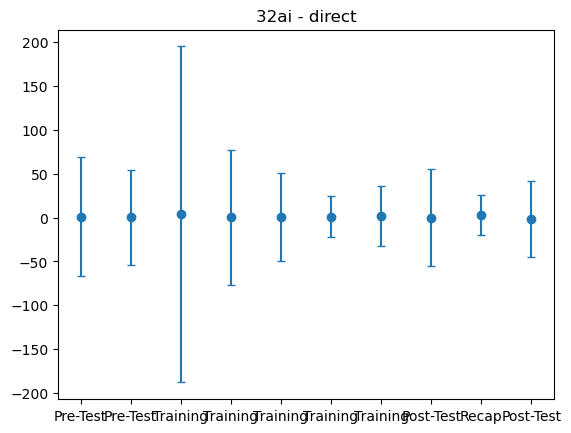

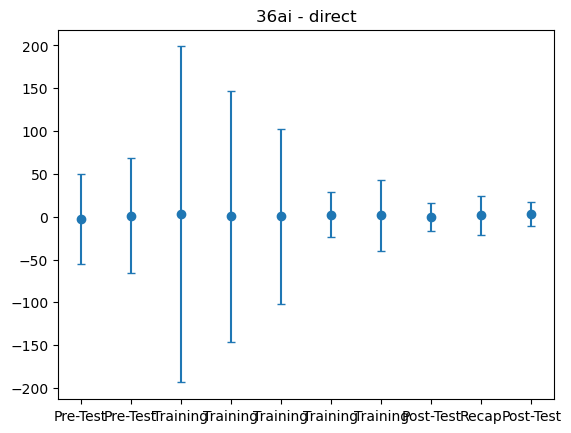

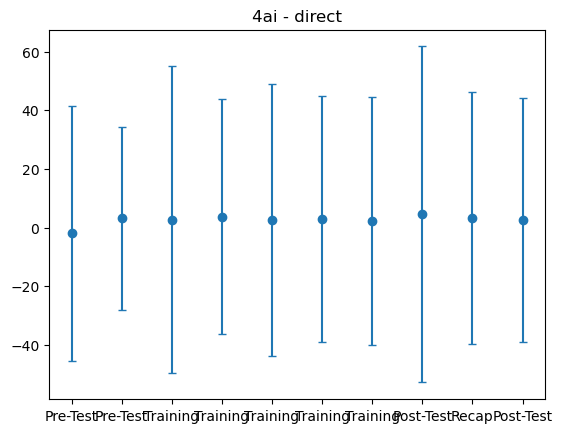

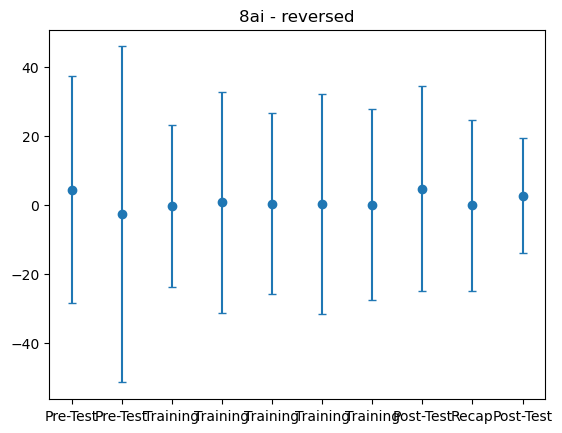

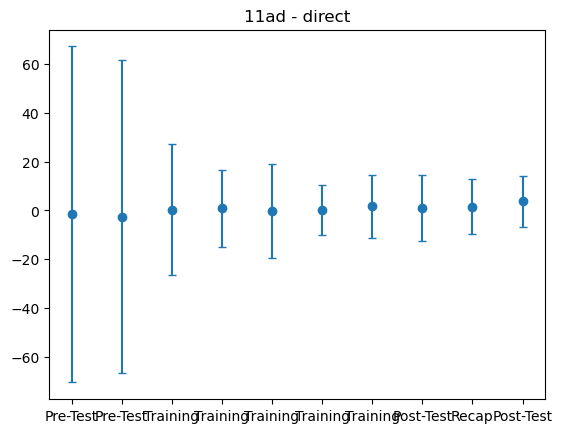

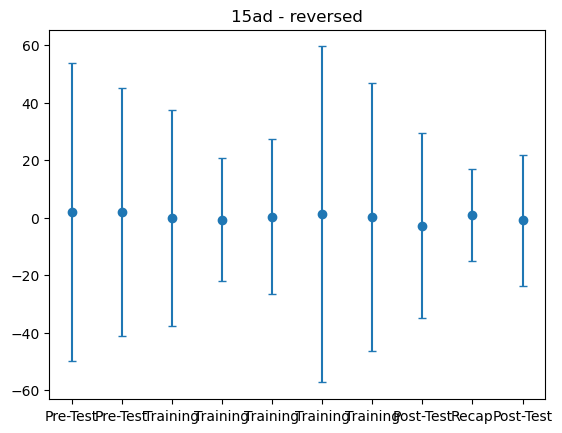

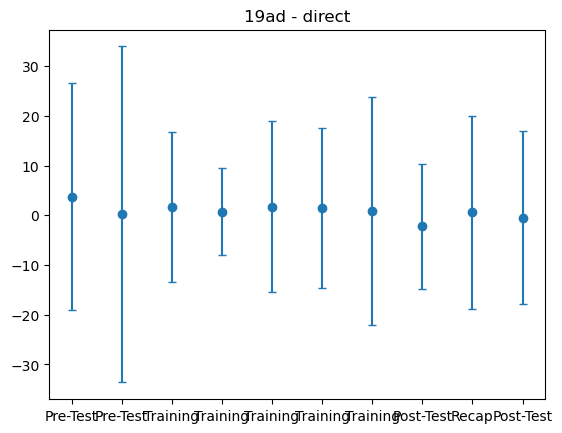

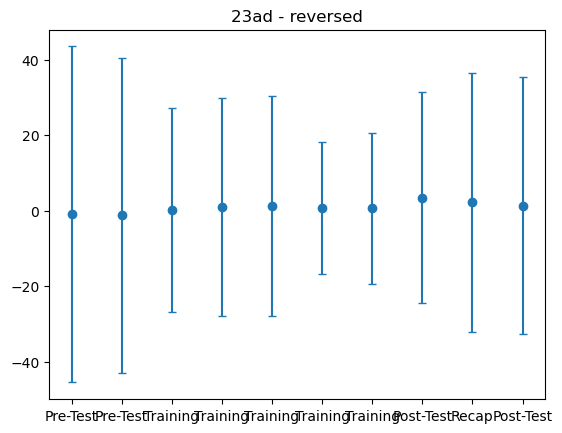

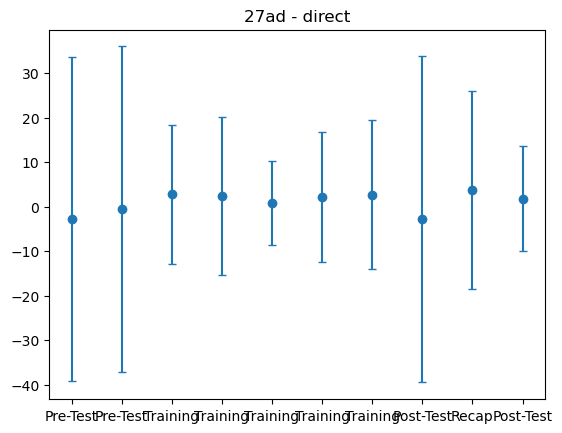

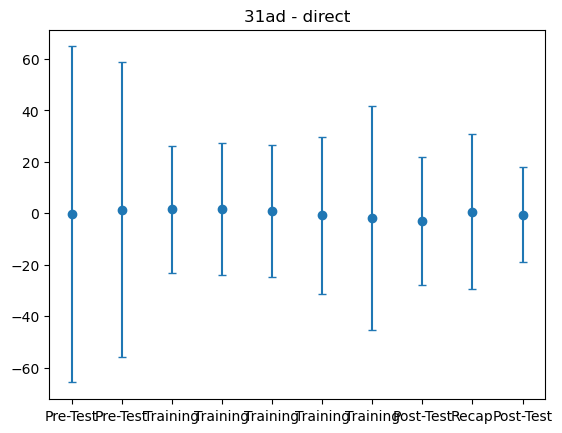

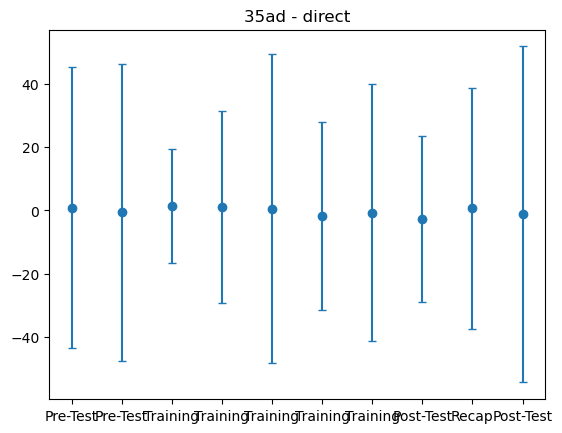

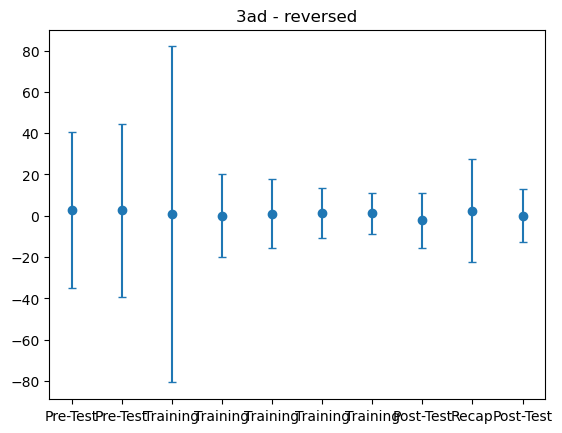

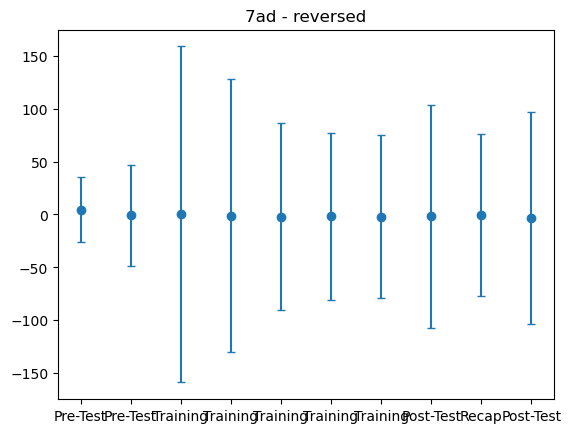

In [ ]:
for condition in [ai_block, ad_block]:
    for participant in condition["participant_id"].unique():
        phases = condition[condition["participant_id"] == participant]
        
        data_points = []
        for phase, task in PHASE_ORDER:
            phase_data = phases[(phases["phase"] == phase) & (phases["task"] == task)]
            for row in phase_data["block"].unique():
                data_points.append((
                    phase,
                    task,
                    row,
                    float(round(phase_data[phase_data["block"] == row]["diff_mean"].iloc[0], 2)),
                    float(round(phase_data[phase_data["block"] == row]["diff_variance"].iloc[0], 2))
                ))
        data_points = np.array(data_points)
        
        plt.title(f"{phases['participant_id'].iloc[0]} - {phases['natural_mapping'].iloc[0]}")

        #print(data_points)
        #plt.scatter(range(len(data_points)), [
        #float(x) for x in data_points[:, 3]])
        plt.errorbar(range(len(data_points)), [float(x) for x in data_points[:, 3]], yerr=[float(x) for x in data_points[:, 4]], fmt="o", capsize=3)
        plt.yticks()
        plt.xticks(list(range(len(data_points))), ["Pre-Test", "Pre-Test", "Training", "Training", "Training", "Training", "Training", "Post-Test", "Recap", "Post-Test"])
        plt.show()

        #diffs = phases["diff_mean"]
        #vars = phases["diff_variance"]
        #plt.scatter(diffs, diffs)